# **TP Final - "Fake News Prediction Dataset"**
Analizar patrones lingüísticos en noticias para identificar potenciales fake news.



Catalina Trevisan - 64990

Moira Patricia Clavin - 64959

María Belén Piuma Justo - 66938

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

import zipfile
import os

# RENOMBRAR
LABEL_NAMES = {1: 'REAL', 0: 'FAKE'}

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Descomprimir el archivo `.zip`

In [ ]:
import os
import zipfile

zip_path = '/content/fake_or_real_news.csv.zip.zip'
extract_dir = '/content/fake_or_real_news/'

# Crear el directorio de extracción si no existe
os.makedirs(extract_dir, exist_ok=True)

# Descomprimir el archivo zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Archivo descomprimido en: {extract_dir}")

# Asumiendo que el archivo CSV se llama 'fake_or_real_news.csv' dentro del zip
file_name = 'fake_or_real_news.csv'
csv_file_path = os.path.join(extract_dir, file_name)

print(f"El archivo CSV se espera en: {csv_file_path}")

Archivo descomprimido en: /content/fake_or_real_news/
El archivo CSV se espera en: /content/fake_or_real_news/fake_or_real_news.csv


### Cargando el archivo CSV en un DataFrame de pandas

In [ ]:
# Usando la ruta del archivo CSV que ya ha sido extraído
df = pd.read_csv(csv_file_path)

# Mostrar las primeras 5 filas del DataFrame
display(df.head(10))

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
5,6903,"Tehran, USA","\nI’m not an immigrant, but my grandparents ...",FAKE
6,7341,Girl Horrified At What She Watches Boyfriend D...,"Share This Baylee Luciani (left), Screenshot o...",FAKE
7,95,‘Britain’s Schindler’ Dies at 106,A Czech stockbroker who saved more than 650 Je...,REAL
8,4869,Fact check: Trump and Clinton at the 'commande...,Hillary Clinton and Donald Trump made some ina...,REAL
9,2909,Iran reportedly makes new push for uranium con...,Iranian negotiators reportedly have made a las...,REAL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
df = df.rename(columns={'Unnamed: 0': 'Id'})

# Distribución de clases

In [ ]:
# Conteo y proporción
df['label'].value_counts()
df['label'].value_counts(normalize=True)



,proportion
label,
REAL,0.500552
FAKE,0.499448


In [ ]:
# Se encodea la variable objetivo: REAL=1, FAKE=0
df['label'] = df['label'].apply(lambda x: 1 if x == 'REAL' else 0)
df['label'].value_counts()

,count
label,
1,3171
0,3164


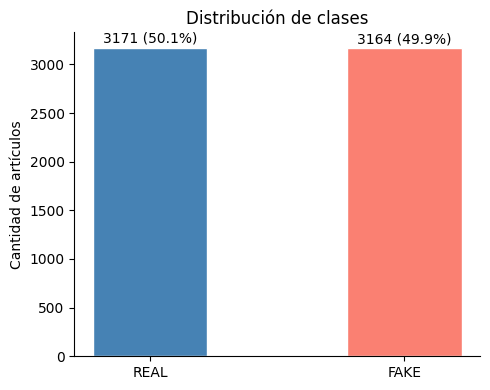

In [ ]:
#DISTRIBUCIÓN
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['label'].value_counts()
bars = ax.bar(
    [LABEL_NAMES[l] for l in counts.index],
    counts.values,
    width=0.45, edgecolor='white', color=['steelblue', 'salmon']

)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribución de clases', fontsize=12)
ax.set_ylabel('Cantidad de artículos')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Longitud de textos y títulos

In [ ]:
df['text_len'] = df['text'].apply(lambda x: len(x.split()))
df['title_len'] = df['title'].apply(lambda x: len(x.split()))

# Estadísticas
df.groupby('label')[['text_len', 'title_len']].describe()

text_len                                                              \
         count        mean         std  min    25%    50%     75%      max   
label                                                                        
0       3164.0  679.129267  958.962790  0.0  212.0  421.0   830.0  20891.0   
1       3171.0  873.257647  722.483569  7.0  450.5  771.0  1123.0   7602.0   

      title_len                                                   
          count       mean       std  min  25%   50%   75%   max  
label                                                             
0        3164.0  11.133059  4.553298  1.0  8.0  11.0  13.0  53.0  
1        3171.0   9.861243  3.199711  2.0  8.0  10.0  12.0  27.0

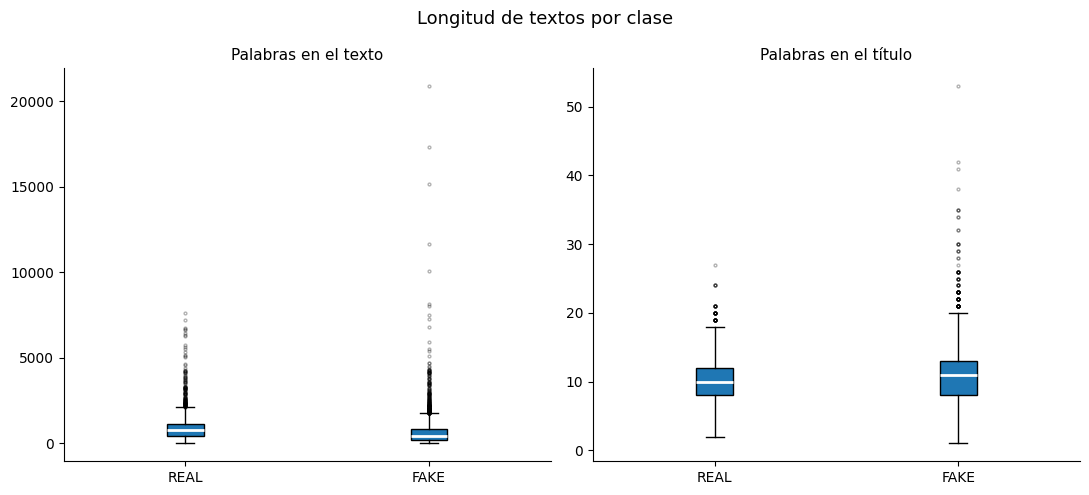

In [ ]:
#BOXPLOT DE LONGITUD PROMEDIO
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, col, title in zip(axes,
                           ['text_len', 'title_len'],
                           ['Palabras en el texto', 'Palabras en el título']):
    data = [df[df['label']==l][col].dropna() for l in [1, 0]]
    bp = ax.boxplot(data, labels=['REAL', 'FAKE'], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(title, fontsize=11)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Longitud de textos por clase', fontsize=13)
plt.tight_layout()
plt.show()

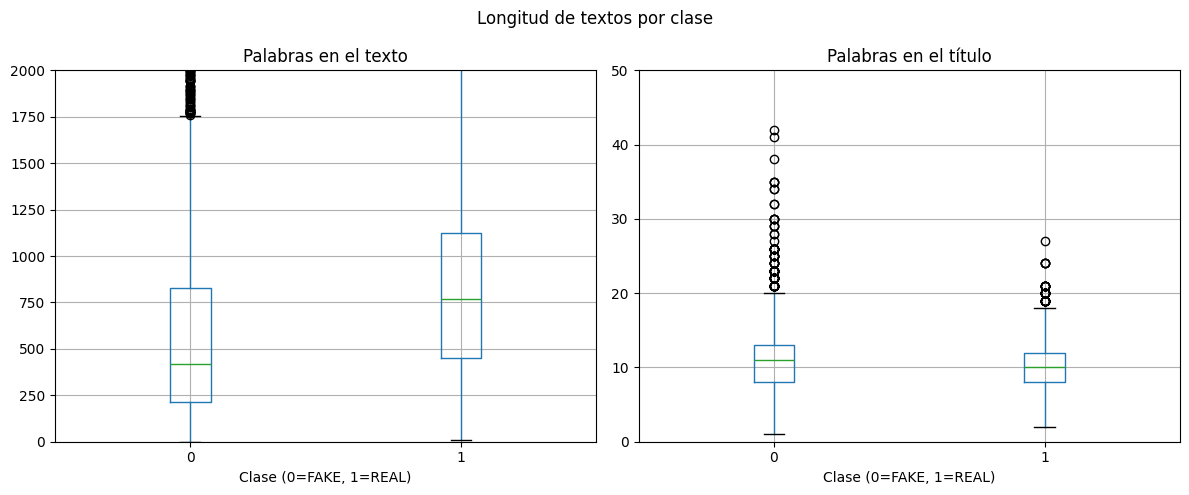

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ['text_len', 'title_len'],
                           ['Palabras en el texto', 'Palabras en el título']):
    df.boxplot(column=col, by='label', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Clase (0=FAKE, 1=REAL)')

# Limitar eje para ignorar outliers extremos
axes[0].set_ylim(0, 2000)   # para el texto
axes[1].set_ylim(0, 50)     # para el título

plt.suptitle('Longitud de textos por clase')
plt.tight_layout()
plt.show()

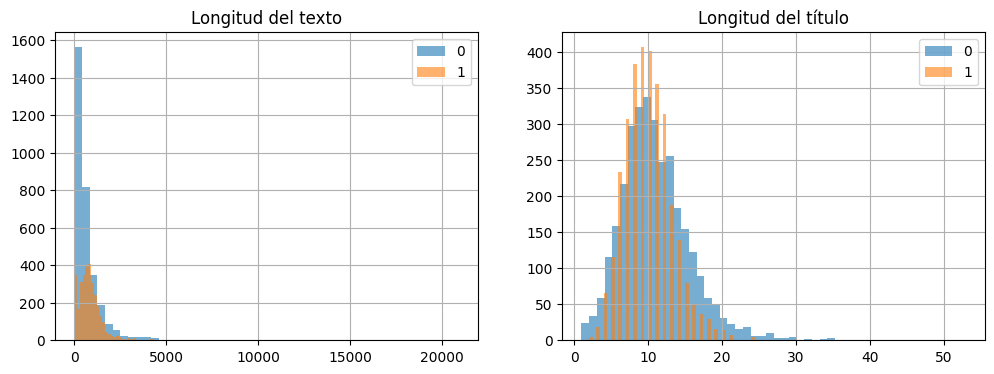

In [ ]:
# Distribución por clase
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['text_len', 'title_len'], ['Longitud del texto', 'Longitud del título']):
    for label in [0, 1]:
        df[df['label'] == label][col].hist(ax=ax, alpha=0.6, bins=50, label=label)
    ax.set_title(title); ax.legend()
plt.show()

¿La diferencia entre REAL y FAKE es significativa?

In [ ]:
# Test estadístico de diferencia
from scipy import stats
for col in ['text_len', 'title_len']:
    real = df[df['label']==1][col]
    fake = df[df['label']==0][col]
    stat, p = stats.mannwhitneyu(real, fake, alternative='two-sided')
    sig = '✓ SIGNIFICATIVO' if p < 0.05 else '✗ no significativo'
    print(f"{col}: p = {p:.4f}  →  {sig}  |  media REAL={real.mean():.0f}, FAKE={fake.mean():.0f}")

text_len: p = 0.0000  →  ✓ SIGNIFICATIVO  |  media REAL=873, FAKE=679
title_len: p = 0.0000  →  ✓ SIGNIFICATIVO  |  media REAL=10, FAKE=11


# Palabras mas frecuentes por clases

In [ ]:
stop_words = set(stopwords.words('english'))

def tokenize_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return [w for w in text.split() if w not in stop_words and len(w) > 2]

df['tokens'] = df['text'].apply(tokenize_clean)

# Type-Token Ratio: diversidad léxica (cuántas palabras distintas usa)
df['ttr'] = df['tokens'].apply(
    lambda t: len(set(t)) / len(t) if len(t) > 0 else 0
)

# Ratio de hapax legomena: palabras que aparecen 1 sola vez (señal de vocabulario inusual)
def hapax_ratio(toks):
    if not toks: return 0
    freq = Counter(toks)
    return sum(1 for v in freq.values() if v == 1) / len(set(toks))

df['hapax_ratio'] = df['tokens'].apply(hapax_ratio)

print("\nRiqueza léxica por clase:")
print(df.groupby('label')[['ttr', 'hapax_ratio']].mean().rename(index=LABEL_NAMES))


Riqueza léxica por clase:
            ttr  hapax_ratio
label                       
FAKE   0.743363     0.799785
REAL   0.720834     0.799566


In [ ]:
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def top_words_func(df, label, n=20):
    all_tokens = [t for toks in df[df['label']==label]['tokens'] for t in toks]
    words = [w for w in all_tokens if w.isalpha() and w not in stop_words]
    return Counter(words).most_common(n)

print("FAKE:", top_words_func(df, 0))
print("REAL:", top_words_func(df, 1))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


FAKE: [('clinton', 5627), ('trump', 5622), ('people', 5072), ('would', 4869), ('one', 4756), ('hillary', 4074), ('said', 3974), ('new', 3447), ('like', 3182), ('also', 3180), ('election', 2896), ('even', 2882), ('world', 2794), ('time', 2783), ('state', 2660), ('government', 2564), ('many', 2555), ('could', 2483), ('president', 2425), ('war', 2329)]
REAL: [('said', 17162), ('trump', 12503), ('clinton', 8707), ('would', 7755), ('one', 6205), ('people', 5932), ('new', 5732), ('president', 5558), ('state', 5512), ('campaign', 5302), ('also', 5027), ('republican', 4836), ('obama', 4634), ('could', 4025), ('states', 3998), ('like', 3793), ('time', 3576), ('party', 3508), ('even', 3505), ('sanders', 3483)]


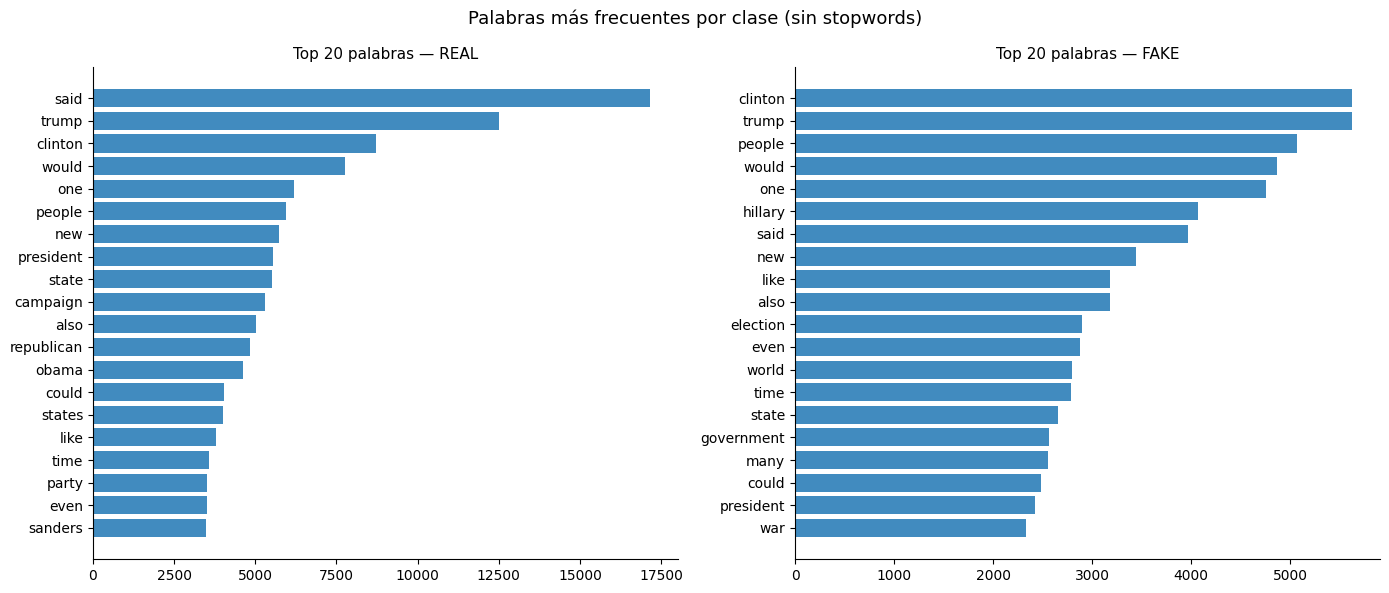

In [ ]:
# Top 20 palabras por clase (barras horizontales)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lbl in zip(axes, [1, 0]):
    all_tokens = [t for toks in df[df['label']==lbl]['tokens'] for t in toks]
    top = Counter(all_tokens).most_common(20)
    words, freqs = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(freqs)),
            alpha=0.85)
    ax.set_title(f'Top 20 palabras — {LABEL_NAMES[lbl]}', fontsize=11)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Palabras más frecuentes por clase (sin stopwords)', fontsize=13)
plt.tight_layout()
plt.show()

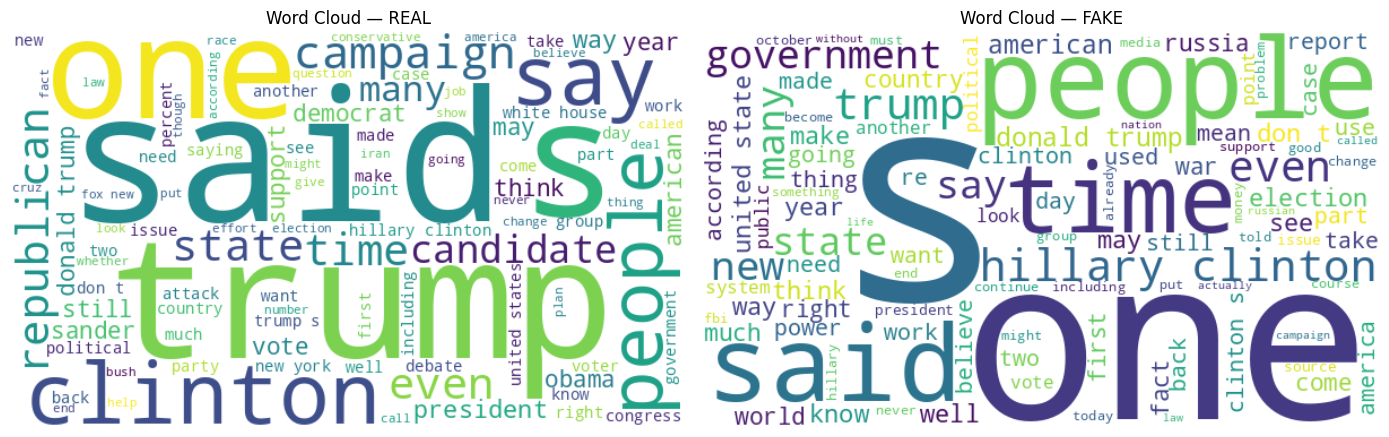

In [ ]:
# Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl in zip(axes, [1, 0]):
    all_tokens = [t for toks in df[df['label']==lbl]['tokens'] for t in toks]
    wc = WordCloud(width=600, height=350, background_color='white',
                   max_words=100).generate(' '.join(all_tokens))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {LABEL_NAMES[lbl]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Análisis de caracteres especiales y mayusculas

Las fake news suelen usar más mayúsculas y signos de exclamación para generar impacto emocional.

In [ ]:
#Cantidad de mayusculas en el título
#Cantidad de ! en el texto

df['caps_ratio'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
df['exclamations'] = df['text'].apply(lambda x: x.count('!'))

print(df.groupby('label')[['caps_ratio', 'exclamations']].mean())

       caps_ratio  exclamations
label                          
0        0.154012      0.796776
1        0.080822      0.261747


In [ ]:

df['question_marks'] = df['text'].apply(lambda x: str(x).count('?'))
df['ellipsis']       = df['text'].apply(lambda x: str(x).count('...'))
df['caps_title']     = df['title'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
)

punct_features = ['caps_ratio', 'exclamations', 'question_marks', 'ellipsis', 'caps_title']

print("\nCaracteres especiales y mayúsculas por clase:")
print(df.groupby('label')[punct_features].mean().rename(index=LABEL_NAMES).round(3))


Caracteres especiales y mayúsculas por clase:
       caps_ratio  exclamations  question_marks  ellipsis  caps_title
label                                                                
FAKE        0.154         0.797           1.780     0.189       0.672
REAL        0.081         0.262           1.294     0.204       0.215


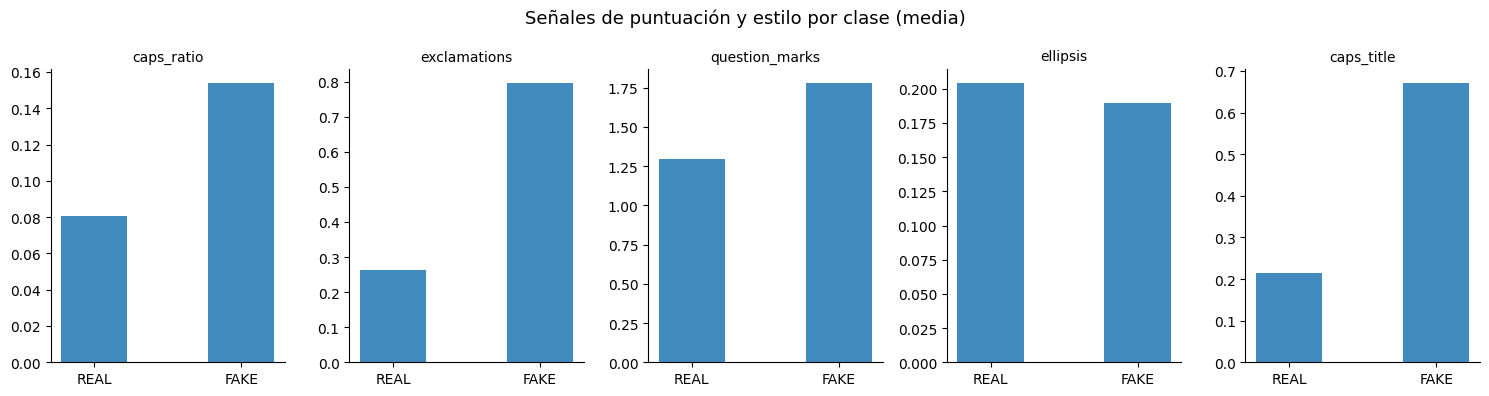

In [ ]:
# Gráfico de barras comparativo
means = df.groupby('label')[punct_features].mean().rename(index=LABEL_NAMES)
fig, axes = plt.subplots(1, len(punct_features), figsize=(15, 4))

for ax, col in zip(axes, punct_features):
    ax.bar(['REAL','FAKE'], [means.loc['REAL', col], means.loc['FAKE', col]],
           width=0.45, alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Señales de puntuación y estilo por clase (media)', fontsize=13)
plt.tight_layout()
plt.show()

Sentimiento y tono

In [ ]:
print("\nCalculando sentimiento")
df[['polarity', 'subjectivity']] = df['text'].apply(
    lambda x: pd.Series(TextBlob(str(x)).sentiment)
)

print("\nSentimiento por clase:")
print(df.groupby('label')[['polarity','subjectivity']].mean().rename(index=LABEL_NAMES).round(3))



Calculando sentimiento

Sentimiento por clase:
       polarity  subjectivity
label                        
FAKE      0.070         0.428
REAL      0.078         0.414


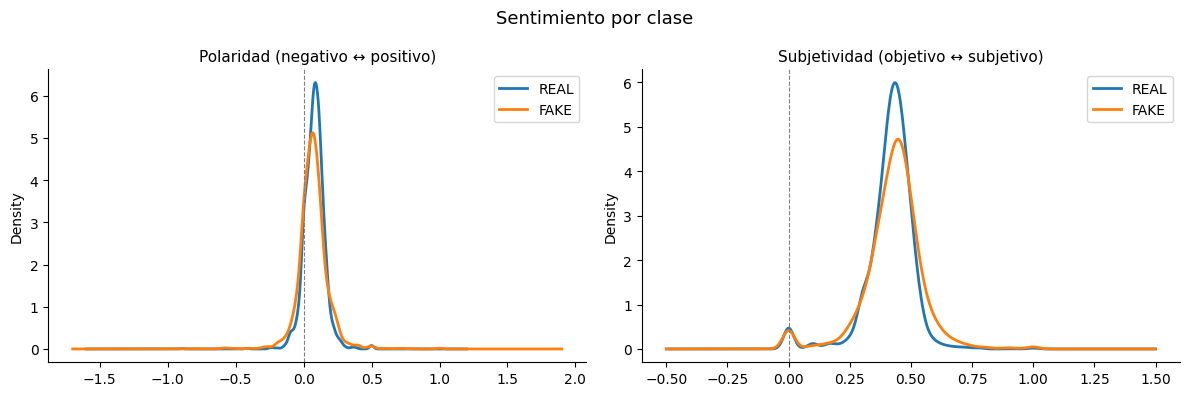

In [ ]:
# KDE de polaridad y subjetividad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, title) in zip(axes, [('polarity',     'Polaridad (negativo ↔ positivo)'),
                                     ('subjectivity', 'Subjetividad (objetivo ↔ subjetivo)')]):
    for lbl in [1, 0]:
        df[df['label']==lbl][col].plot.kde(ax=ax, label=LABEL_NAMES[lbl],
                                            linewidth=2)
    ax.axvline(0, linestyle='--', color='gray', linewidth=0.8)
    ax.set_title(title, fontsize=11)
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Sentimiento por clase', fontsize=13)
plt.tight_layout()
plt.show()

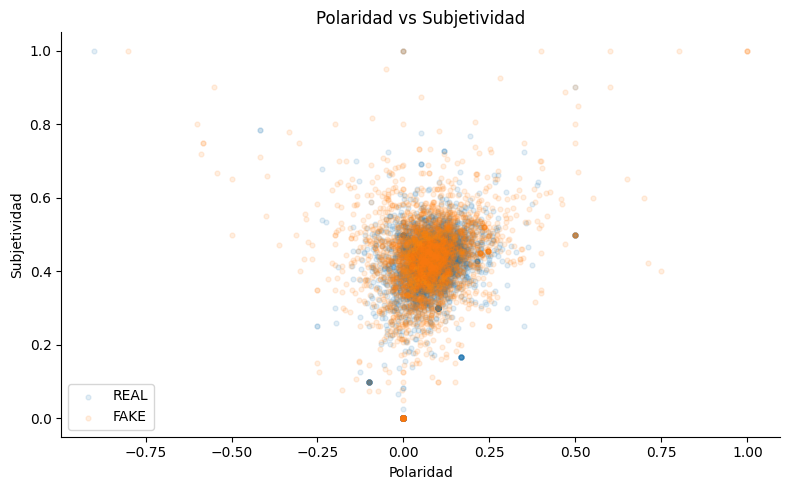

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for lbl in [1, 0]:
    grp = df[df['label']==lbl]
    ax.scatter(grp['polarity'], grp['subjectivity'],
               alpha=0.12, s=12, label=LABEL_NAMES[lbl])

ax.set_xlabel('Polaridad')
ax.set_ylabel('Subjetividad')
ax.set_title('Polaridad vs Subjetividad', fontsize=12)
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

Resumen: correlaciones y poder discriminante

In [ ]:
feature_cols = [
    'text_len', 'title_len',
    'ttr', 'hapax_ratio',
    'caps_ratio', 'exclamations', 'question_marks', 'ellipsis', 'caps_title',
    'polarity', 'subjectivity'
]

corr_label = df[feature_cols + ['label']].corr()['label']
print("\nCorrelación de features con label (positivo → asociado a REAL):")
print(corr_label.round(3))


Correlación de features con label (positivo → asociado a REAL):
text_len          0.114
title_len        -0.160
ttr              -0.091
hapax_ratio      -0.001
caps_ratio       -0.373
exclamations     -0.117
question_marks   -0.061
ellipsis          0.009
caps_title       -0.179
polarity          0.041
subjectivity     -0.062
label             1.000
Name: label, dtype: float64


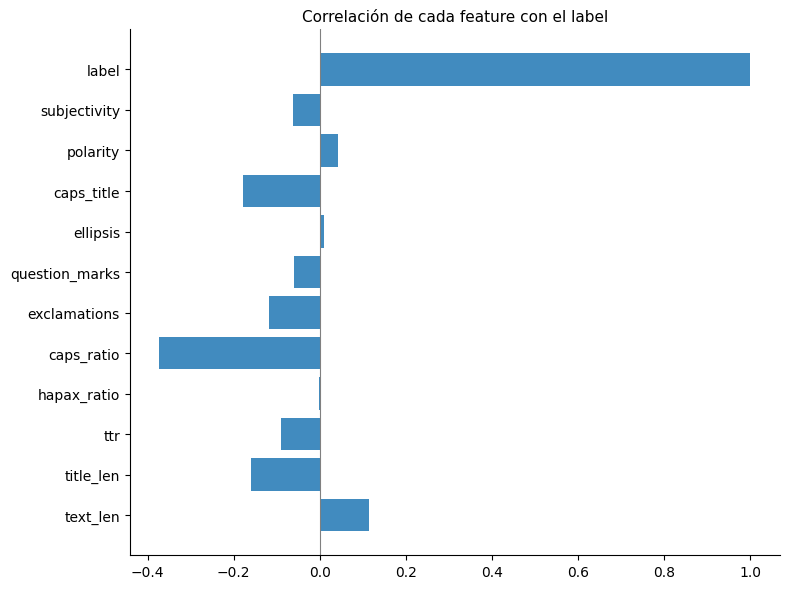

In [ ]:
# Barplot de poder discriminante
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(corr_label.index, corr_label.values, alpha=0.85)

ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Correlación de cada feature con el label', fontsize=11)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

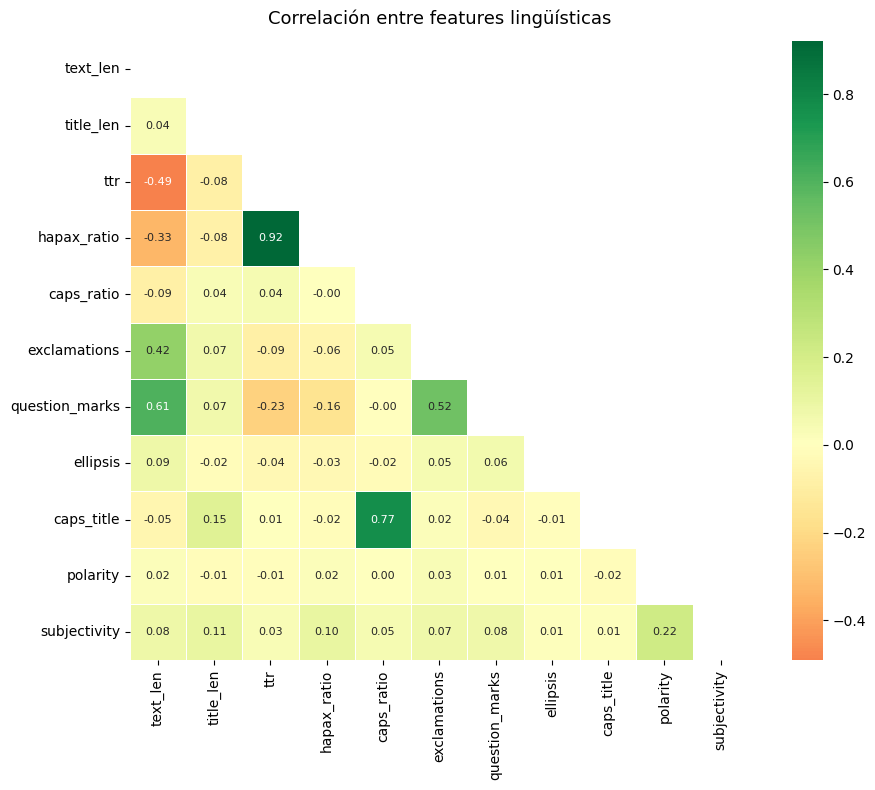

In [ ]:
# Heatmap de correlaciones entre features
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, square=True, annot_kws={'size': 8})
ax.set_title('Correlación entre features lingüísticas', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen final
summary = df.groupby('label')[feature_cols].mean().rename(index=LABEL_NAMES).T
summary['diff_pct'] = ((summary['FAKE'] - summary['REAL']) / summary['REAL'].abs() * 100).round(1)
print("\n=== TABLA RESUMEN: diferencia FAKE vs REAL ===")
print(summary.sort_values('diff_pct', ascending=False).to_string())
print("\nValores positivos → FAKE tiene más de esa característica que REAL")



=== TABLA RESUMEN: diferencia FAKE vs REAL ===
label                 FAKE        REAL  diff_pct
caps_title        0.671618    0.215389     211.8
exclamations      0.796776    0.261747     204.4
caps_ratio        0.154012    0.080822      90.6
question_marks    1.780341    1.293598      37.6
title_len        11.133059    9.861243      12.9
subjectivity      0.428013    0.413879       3.4
ttr               0.743363    0.720834       3.1
hapax_ratio       0.799785    0.799566       0.0
ellipsis          0.189317    0.204352      -7.4
polarity          0.070164    0.078094     -10.2
text_len        679.129267  873.257647     -22.2

Valores positivos → FAKE tiene más de esa característica que REAL


#  Train/Test Split (80/20)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['title', 'text']].copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} noticias")
print(f"Test: {X_test.shape[0]} noticias")
print(f"\nDistribución train:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribución test:\n{y_test.value_counts(normalize=True)}")

Train: 5068 noticias
Test: 1267 noticias

Distribución train:
label
1    0.500592
0    0.499408
Name: proportion, dtype: float64

Distribución test:
label
1    0.500395
0    0.499605
Name: proportion, dtype: float64


# Experimento 0 - Baseline

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Baseline: siempre predice la clase mayoritaria
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== Experimento 0: Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_baseline, target_names=['FAKE', 'REAL']))

=== Experimento 0: Baseline ===
Accuracy: 0.5004

Reporte completo:
              precision    recall  f1-score   support

        FAKE       0.00      0.00      0.00       633
        REAL       0.50      1.00      0.67       634

    accuracy                           0.50      1267
   macro avg       0.25      0.50      0.33      1267
weighted avg       0.25      0.50      0.33      1267



# Experimento 1 - Bag of Words vs TF-IDF

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, confusion_matrix

# Usamos el texto completo (title + text) como input
X_train_text = (X_train['title'] + ' ' + X_train['text']).values
X_test_text = (X_test['title'] + ' ' + X_test['text']).values

# --- Bag of Words ---
bow_vectorizer = CountVectorizer(stop_words='english', lowercase=True, max_features=10000)
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

model_bow = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_bow = cross_val_score(model_bow, X_train_bow, y_train, cv=5, scoring='accuracy')
model_bow.fit(X_train_bow, y_train)
y_pred_bow = model_bow.predict(X_test_bow)

print("=== BoW + Regresión Logística ===")
print(f"CV Accuracy (k=5): {cv_scores_bow.mean():.4f} (+/- {cv_scores_bow.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_bow):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_bow):.4f}")

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(stop_words='english', lowercase=True, max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

model_tfidf = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_tfidf = cross_val_score(model_tfidf, X_train_tfidf, y_train, cv=5, scoring='accuracy')
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("\n=== TF-IDF + Regresión Logística ===")
print(f"CV Accuracy (k=5): {cv_scores_tfidf.mean():.4f} (+/- {cv_scores_tfidf.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_tfidf):.4f}")

# TF-IDF SIN lowercase (conservando mayúsculas)
tfidf_caps = TfidfVectorizer(stop_words='english', lowercase=False, max_features=10000)
X_train_caps = tfidf_caps.fit_transform(X_train_text)
X_test_caps = tfidf_caps.transform(X_test_text)

model_caps = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_caps = cross_val_score(model_caps, X_train_caps, y_train, cv=5, scoring='accuracy')
model_caps.fit(X_train_caps, y_train)
y_pred_caps = model_caps.predict(X_test_caps)

print("=== TF-IDF sin normalizar mayúsculas + RL ===")
print(f"CV Accuracy (k=5): {cv_scores_caps.mean():.4f} (+/- {cv_scores_caps.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_caps):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_caps):.4f}")

=== BoW + Regresión Logística ===
CV Accuracy (k=5): 0.9146 (+/- 0.0068)
Test Accuracy: 0.9258
Test F1-score: 0.9248

=== TF-IDF + Regresión Logística ===
CV Accuracy (k=5): 0.9110 (+/- 0.0098)
Test Accuracy: 0.9219
Test F1-score: 0.9205
=== TF-IDF sin normalizar mayúsculas + RL ===
CV Accuracy (k=5): 0.9161 (+/- 0.0068)
Test Accuracy: 0.9361
Test F1-score: 0.9355


Ambos superan ampliamente el baseline (0.50 → ~0.92). Pero hay un resultado contraintuitivo: BoW funcionó un poquito mejor que TF-IDF, cuando la hipótesis era que TF-IDF sería superior.
Esto en realidad es un resultado interesante para discutir en la presentación. Posibles explicaciones:

La diferencia es muy chica (0.004 en accuracy) y podría no ser significativa
Con max_features=10000 ambas representaciones ya capturan las palabras más informativas, reduciendo la ventaja teórica de TF-IDF
TF-IDF "downweightea" palabras frecuentes, pero en este dataset algunas palabras frecuentes (como nombres propios "Clinton", "Trump") podrían ser justamente las más discriminativas

En cuanto a las mayúsculas, conservarlas mejora el modelo en más de 1 punto porcentual (0.9219 → 0.9361), confirmando justo lo que habían hipotetizado en base al EDA: las mayúsculas son una señal discriminante y normalizarlas a minúsculas hace perder información útil.

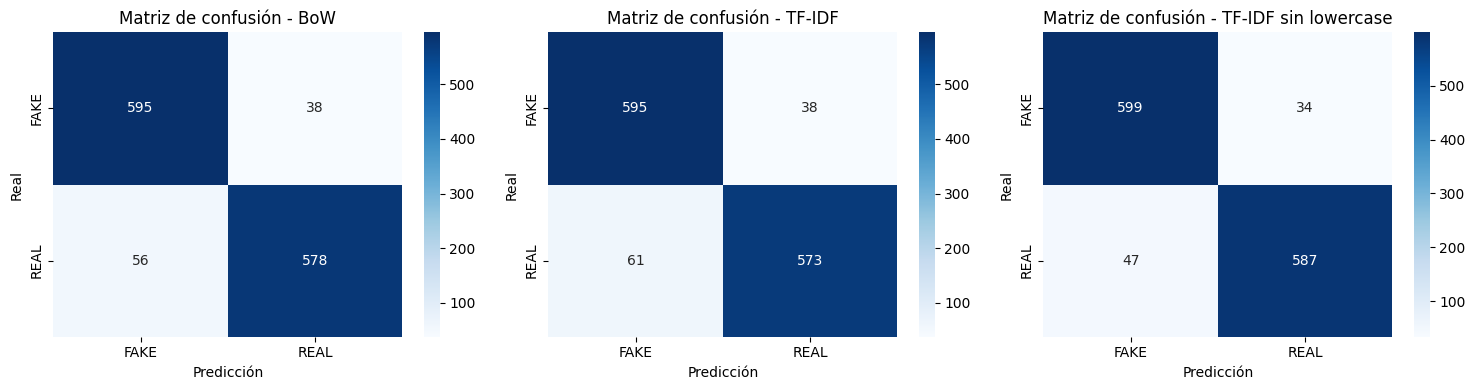

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, y_pred, title in zip(axes, [y_pred_bow, y_pred_tfidf, y_pred_caps],
                               ['BoW', 'TF-IDF', 'TF-IDF sin lowercase']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
    ax.set_title(f'Matriz de confusión - {title}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

Las tres matrices presentan un patrón similar, con errores relativamente simétricos entre clases (FAKE clasificado como REAL ≈ REAL clasificado como FAKE), lo cual es una buena señal ya que indica que los modelos no presentan un sesgo fuerte hacia ninguna clase en particular. Sin embargo, el modelo TF-IDF sin normalización a minúsculas se destaca por reducir la cantidad total de errores en ambas direcciones (34 falsos positivos y 47 falsos negativos), frente a los 38 y 56-61 observados en BoW y TF-IDF estándar respectivamente, confirmando que la mejora en accuracy se debe a una mayor capacidad de discriminación general y no a un desplazamiento del error hacia una sola clase.

# Experimento 2: Naive Bayes vs Regresión Logística (con TF-IDF)

=== Naive Bayes + TF-IDF ===
CV Accuracy (k=5): 0.8891 (+/- 0.0064)
Test Accuracy: 0.8856
Test F1-score: 0.8866

=== Regresión Logística + TF-IDF (de Experimento 1) ===
CV Accuracy (k=5): 0.9110 (+/- 0.0098)
Test Accuracy: 0.9219
Test F1-score: 0.9205


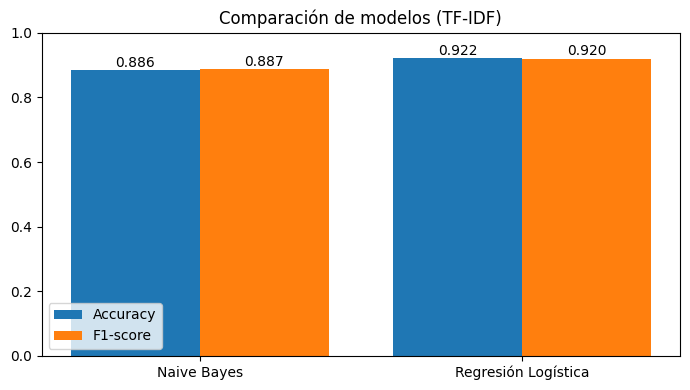

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# --- Multinomial Naive Bayes ---
model_nb = MultinomialNB()
cv_scores_nb = cross_val_score(model_nb, X_train_tfidf, y_train, cv=5, scoring='accuracy')
model_nb.fit(X_train_tfidf, y_train)
y_pred_nb = model_nb.predict(X_test_tfidf)

print("=== Naive Bayes + TF-IDF ===")
print(f"CV Accuracy (k=5): {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_nb):.4f}")

# --- Regresión Logística (ya entrenado en Experimento 1 como model_tfidf) ---
print("\n=== Regresión Logística + TF-IDF (de Experimento 1) ===")
print(f"CV Accuracy (k=5): {cv_scores_tfidf.mean():.4f} (+/- {cv_scores_tfidf.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_tfidf):.4f}")

# --- Comparación visual ---
fig, ax = plt.subplots(figsize=(7, 4))
modelos = ['Naive Bayes', 'Regresión Logística']
accs = [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_tfidf)]
f1s = [f1_score(y_test, y_pred_nb), f1_score(y_test, y_pred_tfidf)]

x = range(len(modelos))
ax.bar([i-0.2 for i in x], accs, width=0.4, label='Accuracy')
ax.bar([i+0.2 for i in x], f1s, width=0.4, label='F1-score')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Comparación de modelos (TF-IDF)')
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i-0.2, a+0.01, f'{a:.3f}', ha='center')
    ax.text(i+0.2, f+0.01, f'{f:.3f}', ha='center')
plt.tight_layout()
plt.show()

Regresión Logística supera a Naive Bayes por ~3.6 puntos en accuracy. Esto confirma la hipótesis: el supuesto de independencia entre features de Naive Bayes parece ser una limitación real para esta tarea, mientras que Regresión Logística logra capturar mejor las relaciones entre palabras.

#  Experimento 3: TF-IDF solo vs TF-IDF + features estilísticas

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

# Features estilísticas/estructurales ya calculadas en el EDA
style_features = ['text_len', 'title_len', 'caps_ratio', 'exclamations',
                   'question_marks', 'polarity', 'subjectivity']

X_train_style = df.loc[X_train.index, style_features].values
X_test_style = df.loc[X_test.index, style_features].values

# Escalar las features numéricas (TF-IDF ya está en escala 0-1)
scaler = StandardScaler()
X_train_style_scaled = scaler.fit_transform(X_train_style)
X_test_style_scaled = scaler.transform(X_test_style)

# Combinar TF-IDF (sparse) + features estilísticas (dense)
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_style_scaled)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(X_test_style_scaled)])

# --- Modelo combinado ---
model_combined = LogisticRegression(max_iter=1000, random_state=42)
cv_scores_combined = cross_val_score(model_combined, X_train_combined, y_train, cv=5, scoring='accuracy')
model_combined.fit(X_train_combined, y_train)
y_pred_combined = model_combined.predict(X_test_combined)

print("=== TF-IDF + Features estilísticas + Regresión Logística ===")
print(f"CV Accuracy (k=5): {cv_scores_combined.mean():.4f} (+/- {cv_scores_combined.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_combined):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_combined):.4f}")

print("\n=== TF-IDF solo (de Experimento 1) ===")
print(f"CV Accuracy (k=5): {cv_scores_tfidf.mean():.4f} (+/- {cv_scores_tfidf.std():.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print(f"Test F1-score: {f1_score(y_test, y_pred_tfidf):.4f}")

=== TF-IDF + Features estilísticas + Regresión Logística ===
CV Accuracy (k=5): 0.9110 (+/- 0.0064)
Test Accuracy: 0.9250
Test F1-score: 0.9249

=== TF-IDF solo (de Experimento 1) ===
CV Accuracy (k=5): 0.9110 (+/- 0.0098)
Test Accuracy: 0.9219
Test F1-score: 0.9205


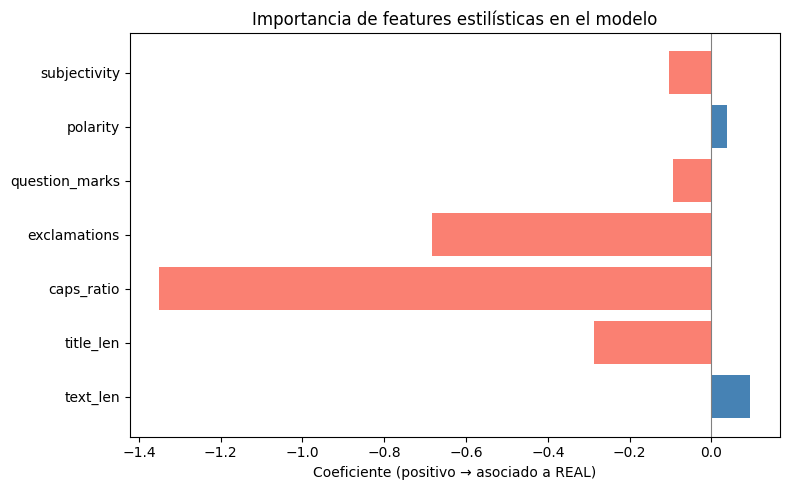

Coeficientes de features estilísticas:
text_len: 0.0955
title_len: -0.2872
caps_ratio: -1.3502
exclamations: -0.6833
question_marks: -0.0929
polarity: 0.0382
subjectivity: -0.1040


In [ ]:
#Análisis de coeficientes

# Nombres de las features: vocabulario TF-IDF + features estilísticas
feature_names = list(tfidf_vectorizer.get_feature_names_out()) + style_features
coefs = model_combined.coef_[0]

# Coeficientes de las features estilísticas (las últimas 7)
style_coefs = coefs[-len(style_features):]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'salmon' for c in style_coefs]
ax.barh(style_features, style_coefs, color=colors)
ax.set_xlabel('Coeficiente (positivo → asociado a REAL)')
ax.set_title('Importancia de features estilísticas en el modelo')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Coeficientes de features estilísticas:")
for name, coef in zip(style_features, style_coefs):
    print(f"{name}: {coef:.4f}")

Resultado muy claro y consistente con todo el EDA:

Interpretación de los coeficientes:

* caps_ratio (-1.35) → la feature más influyente por lejos. Mayor proporción de mayúsculas en el texto está fuertemente asociada a FAKE
* exclamations (-0.68) → más signos de exclamación también asociado a FAKE
* title_len (-0.29) → títulos más largos, levemente asociado a FAKE
* text_len (+0.10) → textos más largos, levemente asociado a REAL (consistente con la Figura 2)
* polarity, subjectivity, question_marks → coeficientes muy chicos, prácticamente sin influencia


Conclusión del experimento 3
Esto confirma perfectamente las hipótesis del EDA: las variables estilísticas relacionadas con mayúsculas y puntuación (caps_ratio, exclamations) son las que más aportan, mientras que polaridad y subjetividad (TextBlob) tienen peso casi nulo — tal como habían anticipado al analizar las Figuras 4 y 5.


# Análisis de errores

In [ ]:
# Identificar errores del mejor modelo (TF-IDF sin lowercase)
errores_idx = X_test.index[y_test.values != y_pred_caps]
errores_df = df.loc[errores_idx, ['title', 'text', 'label']].copy()
errores_df['prediccion'] = y_pred_caps[y_test.values != y_pred_caps]

print(f"Total de errores: {len(errores_df)}")
print("\nEjemplos de noticias mal clasificadas:")
for idx, row in errores_df.head(3).iterrows():
    print(f"\nTítulo: {row['title']}")
    print(f"Real: {LABEL_NAMES[row['label']]} | Predicho: {LABEL_NAMES[row['prediccion']]}")

Total de errores: 81

Ejemplos de noticias mal clasificadas:

Título: Israel votes: Netanyahu's last-ditch vow to his base – a dead peace process (+video)
Real: REAL | Predicho: FAKE

Título: Donald Trump is going to win: This is why Hillary Clinton can’t defeat what Trump represents
Real: REAL | Predicho: FAKE

Título: CLINTON: I’D ADD MICHELLE OBAMA TO MY CABINET
Real: FAKE | Predicho: REAL
